<a href="https://colab.research.google.com/github/naikwadesharvil/mental-health-detection-nlp/blob/main/01_data_exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
# Install required libraries
!pip install transformers datasets torch scikit-learn
!pip install lime shap wandb
!pip install pandas numpy matplotlib seaborn
!pip install nltk emoji contractions

print("All libraries installed successfully!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 8.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=2beed2bf1b83d6b0000c9fd0f5407b756e7156d914f5aaee13a9953c90374c6d
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 19.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 37.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 15.2 MB/s eta 0:00:00
All libraries installed successfully!


In [5]:
import torch

print("Checking GPU Availability...")
print(f"CUDA Available: {torch.cuda.is_available()}")
print(f"CUDA Device Count: {torch.cuda.device_count()}")
if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
print("\n Setup verification complete!")

Checking GPU Availability...
CUDA Available: True
CUDA Device Count: 1
GPU Name: Tesla T4
GPU Memory: 15.64 GB

 Setup verification complete!


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully! 🚀")

# 🌟 NEW STABLE DATASET URL 🌟
# This is a widely used dataset for detecting depressed/suicidal intention in tweets
url = "https://raw.githubusercontent.com/laxmimerit/twitter-suicidal-intention-dataset/master/twitter-suicidal_data.csv"

# Load the dataset using Pandas
df = pd.read_csv(url)

# This dataset has columns: 'tweet' and 'intention'.
# We will rename 'intention' to 'label' so it works perfectly with the rest of your code!
df = df.rename(columns={'intention': 'label'})

print(f"Dataset loaded! We have {df.shape[0]} rows and {df.shape[1]} columns.")
display(df.head()) # This will show the first 5 rows

Libraries imported successfully! 🚀
Dataset loaded! We have 9119 rows and 2 columns.


,tweet,label
0,my life is meaningless i just want to end my l...,1
1,muttering i wanna die to myself daily for a fe...,1
2,work slave i really feel like my only purpose ...,1
3,i did something on the 2 of october i overdose...,1
4,i feel like no one cares i just want to die ma...,1


Missing values in each column:
 tweet    0
label    0
dtype: int64


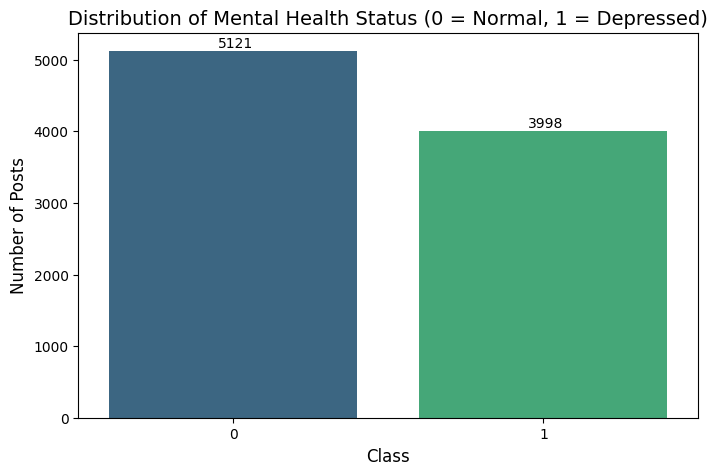

Normal Posts: 56.16%
Depressed Posts: 43.84%


In [7]:
# Check for missing values
print("Missing values in each column:\n", df.isnull().sum())
# Plot the distribution of our classes
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='label', palette='viridis')
plt.title('Distribution of Mental Health Status (0 = Normal, 1 = Depressed)', fontsize=14)
plt.xlabel('Class', fontsize=12)
plt.ylabel('Number of Posts', fontsize=12)
# Add exact numbers on top of the bars
for p in plt.gca().patches:
    plt.gca().annotate(f'{int(p.get_height())}', (p.get_x() + 0.35, p.get_height() + 50))
plt.show()
# Calculate exact percentages
normal_pct = (df['label'] == 0).mean() * 100
dep_pct = (df['label'] == 1).mean() * 100
print(f"Normal Posts: {normal_pct:.2f}%")
print(f"Depressed Posts: {dep_pct:.2f}%")

In [8]:
from nltk.stem import WordNetLemmatizer
import nltk
nltk.download('wordnet')
import pandas as pd
import re
from nltk.corpus import stopwords
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

print(df.columns)

lemmatizer = WordNetLemmatizer()

def clean_text(text):
    if pd.isna(text):
        return ""

    text = text.lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'\@\w+|\#', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()

    words = text.split()
    words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]

    return ' '.join(words)

df['clean_text'] = df['tweet'].apply(clean_text)
print(df.head())

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Index(['tweet', 'label'], dtype='object')
                                               tweet  label  \
0  my life is meaningless i just want to end my l...      1   
1  muttering i wanna die to myself daily for a fe...      1   
2  work slave i really feel like my only purpose ...      1   
3  i did something on the 2 of october i overdose...      1   
4  i feel like no one cares i just want to die ma...      1   

                                          clean_text  
0  life meaningless want end life badly life comp...  
1  muttering wanna die daily month feel worthless...  
2  work slave really feel like purpose life make ...  
3  something october overdosed felt alone horribl...  
4  feel like one care want die maybe feel less lo...  


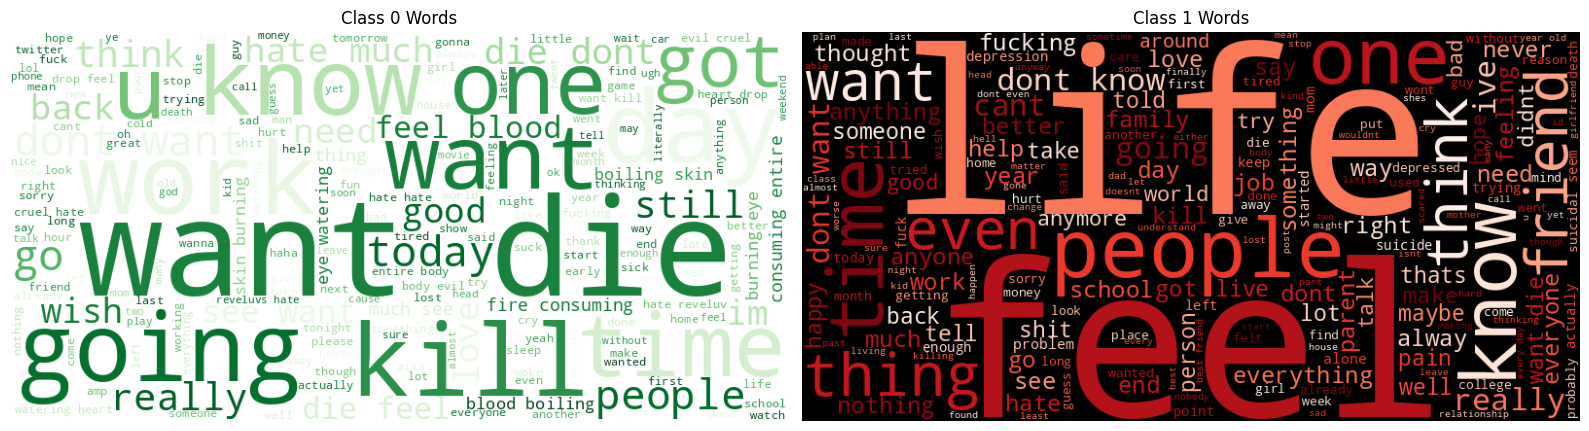

In [9]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Remove empty values
normal_df = df[(df['label'] == 0) & (df['clean_text'] != "")]
depressed_df = df[(df['label'] == 1) & (df['clean_text'] != "")]

normal_text = ' '.join(normal_df['clean_text'])
depressed_text = ' '.join(depressed_df['clean_text'])

plt.figure(figsize=(16, 8))

# Normal / Positive
plt.subplot(1, 2, 1)
if normal_text.strip():
    wc1 = WordCloud(width=800, height=400, background_color='white', colormap='Greens').generate(normal_text)
    plt.imshow(wc1)
plt.title('Class 0 Words')
plt.axis('off')

# Depressed / Negative
plt.subplot(1, 2, 2)
if depressed_text.strip():
    wc2 = WordCloud(width=800, height=400, background_color='black', colormap='Reds').generate(depressed_text)
    plt.imshow(wc2)
plt.title('Class 1 Words')
plt.axis('off')

plt.tight_layout()
plt.show()

In [10]:
from sklearn.model_selection import train_test_split

# Use clean_text for baseline ML
X = df["clean_text"].fillna("")
y = df["label"].astype(int)

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print("Train:", len(X_train), "Val:", len(X_val), "Test:", len(X_test))
print("Train distribution:\n", y_train.value_counts(normalize=True))

Train: 7295 Val: 912 Test: 912
Train distribution:
 label
0    0.561618
1    0.438382
Name: proportion, dtype: float64


In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

tfidf = TfidfVectorizer(
    max_features=30000,
    ngram_range=(1,2),
    min_df=2
)

X_train_vec = tfidf.fit_transform(X_train)
X_val_vec   = tfidf.transform(X_val)

clf = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",   # good default for mental-health datasets
    n_jobs=None
)
clf.fit(X_train_vec, y_train)

val_pred = clf.predict(X_val_vec)
val_prob = clf.predict_proba(X_val_vec)[:, 1]

=== TF-IDF + Logistic Regression (Validation) ===
              precision    recall  f1-score   support

           0     0.8727    0.9238    0.8975       512
           1     0.8946    0.8275    0.8597       400

    accuracy                         0.8816       912
   macro avg     0.8836    0.8757    0.8786       912
weighted avg     0.8823    0.8816    0.8810       912



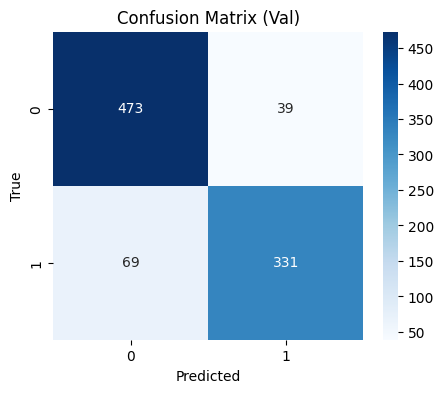

ROC-AUC (Val): 0.95531494140625


In [12]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt

print("=== TF-IDF + Logistic Regression (Validation) ===")
print(classification_report(y_val, val_pred, digits=4))

cm = confusion_matrix(y_val, val_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix (Val)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

print("ROC-AUC (Val):", roc_auc_score(y_val, val_prob))

In [13]:
X_test_vec = tfidf.transform(X_test)
test_pred  = clf.predict(X_test_vec)
test_prob  = clf.predict_proba(X_test_vec)[:, 1]

print("=== TF-IDF + Logistic Regression (Test) ===")
print(classification_report(y_test, test_pred, digits=4))
print("ROC-AUC (Test):", roc_auc_score(y_test, test_prob))

=== TF-IDF + Logistic Regression (Test) ===
              precision    recall  f1-score   support

           0     0.9011    0.9434    0.9218       512
           1     0.9229    0.8675    0.8943       400

    accuracy                         0.9101       912
   macro avg     0.9120    0.9054    0.9080       912
weighted avg     0.9107    0.9101    0.9097       912

ROC-AUC (Test): 0.9704443359375001


In [14]:
import os, json
import joblib
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

os.makedirs("models", exist_ok=True)
os.makedirs("results/metrics", exist_ok=True)

joblib.dump(tfidf, "models/tfidf_vectorizer.joblib")
joblib.dump(clf, "models/logreg_tfidf.joblib")

metrics = {
    "model": "tfidf_logreg",
    "val_accuracy": float(accuracy_score(y_val, val_pred)),
    "val_precision": float(precision_score(y_val, val_pred)),
    "val_recall": float(recall_score(y_val, val_pred)),
    "val_f1": float(f1_score(y_val, val_pred)),
    "val_roc_auc": float(roc_auc_score(y_val, val_prob)),
}

with open("results/metrics/tfidf_logreg_val_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

print("✅ Saved models/ and results/metrics/")
print(metrics)

✅ Saved models/ and results/metrics/
{'model': 'tfidf_logreg', 'val_accuracy': 0.881578947368421, 'val_precision': 0.8945945945945946, 'val_recall': 0.8275, 'val_f1': 0.8597402597402597, 'val_roc_auc': 0.95531494140625}


In [15]:
from google.colab import files
files.download("models/logreg_tfidf.joblib")
files.download("models/tfidf_vectorizer.joblib")
files.download("results/metrics/tfidf_logreg_val_metrics.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>